# LIDC-IDRI COLIPRI embeddings

This notebook demonstrates how to use the clean LIDC-IDRI 3D CT dataset with COLIPRI. It reads the CT-level labels, selects example CT volumes from the dataset, converts the `.npz` arrays into TorchIO images, compares the volumes with simple lung nodule prompts, extracts image embeddings, and visualizes the embeddings with PCA.

The clean CT arrays are stored as `(height, width, slices)`. COLIPRI/TorchIO expects a channel-first 3D image tensor, so the notebook wraps each volume as a `torchio.ScalarImage`.

----

Este notebook muestra cómo usar el dataset 3D LIDC-IDRI con COLIPRI. Lee las etiquetas a nivel CT, selecciona ejemplos de volúmenes CT desde el dataset, convierte los `.npz` en imágenes TorchIO, compara los volúmenes con prompts simples sobre nódulos pulmonares, extrae embeddings de imagen y visualiza los embeddings con PCA.

Los arreglos CT limpios están guardados como `(height, width, slices)`. COLIPRI/TorchIO espera un tensor 3D con canal primero, por eso el notebook envuelve cada volumen como `torchio.ScalarImage`.


In [1]:
from pathlib import Path
import os
import time

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import torch
import torchio as tio

import colipri
from colipri import ZeroShotImageClassificationPipeline, get_model, get_processor

load_dotenv()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Last run on", time.ctime())
print("colipri version:", colipri.__version__)
print("device:", device)


Last run on Wed Jun 17 04:01:31 2026
colipri version: 0.1.1
device: cpu


In [2]:
# Reemplazar con tu ruta al dataset
#DATASET_DIR = Path("PATH-TO-DATASET/LIDC-IDRI-clean-224")
DATASET_DIR = Path(os.environ["SCRATCH"]) / "datasets" / "datatondatasets" / "LIDC-IDRI-clean-224"

ct_level = pd.read_csv(DATASET_DIR / "ct_level.csv")
print(ct_level.shape)
ct_level.head()


(1018, 33)


,volume_path,split,patient_id,study_instance_uid,series_instance_uid,num_slices,height,width,array_axis_order,original_num_slices,...,nodule_ids,annotation_ids,malignancy_scores,max_malignancy,mean_malignancy,median_malignancy,has_malignant_or_high_suspicion,has_indeterminate,has_benign_or_low_suspicion,ct_malignancy_class
0,volumes/lidc_ct_0001_225eb1547cd0.npz,train,LIDC-IDRI-1001,1.3.6.1.4.1.14519.5.2.1.6279.6001.281499745765...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,194,224,224,"height,width,slices",194,...,0|2141|2148|22127|22134|Nodule 001|Nodule 003,tcia-lidc-xml/188/104.xml|259497035|0|tcia-lid...,4|3|1|2|3|4|2,4.0,2.714286,3.0,1,1,1,malignant_or_high_suspicion
1,volumes/lidc_ct_0002_7e39f4682b57.npz,test,LIDC-IDRI-0778,1.3.6.1.4.1.14519.5.2.1.6279.6001.174809695196...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840...,481,224,224,"height,width,slices",481,...,1,tcia-lidc-xml/189/027.xml|anon|1,3,3.0,3.000000,3.0,0,1,0,indeterminate
2,volumes/lidc_ct_0003_1ae565a9fe4d.npz,train,LIDC-IDRI-0813,1.3.6.1.4.1.14519.5.2.1.6279.6001.139110171863...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,157,224,224,"height,width,slices",157,...,3|6|MI014_8002|Nodule 002|Nodule 003|Nodule 004,tcia-lidc-xml/188/292.xml|-1598355637|3|tcia-l...,3|4|3|3|1|3,4.0,2.833333,3.0,1,1,1,malignant_or_high_suspicion
3,volumes/lidc_ct_0004_996fb0eba034.npz,train,LIDC-IDRI-0710,1.3.6.1.4.1.14519.5.2.1.6279.6001.116146223752...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100530488926...,471,224,224,"height,width,slices",471,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,no_label
4,volumes/lidc_ct_0005_238e610d30a4.npz,train,LIDC-IDRI-0410,1.3.6.1.4.1.14519.5.2.1.6279.6001.818775038273...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482...,126,224,224,"height,width,slices",126,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,no_label


In [3]:
# Pick one positive/high-suspicion CT if available, plus one additional CT.
if "has_malignant_or_high_suspicion" in ct_level.columns and (ct_level["has_malignant_or_high_suspicion"] == 1).any():
    sample = ct_level[ct_level["has_malignant_or_high_suspicion"] == 1].head(1)
    sample = pd.concat([sample, ct_level.drop(sample.index).head(1)], ignore_index=True)
else:
    sample = ct_level.head(2).reset_index(drop=True)

sample[["volume_path", "ct_malignancy_class", "has_malignant_or_high_suspicion", "num_slices", "height", "width"]]


,volume_path,ct_malignancy_class,has_malignant_or_high_suspicion,num_slices,height,width
0,volumes/lidc_ct_0001_225eb1547cd0.npz,malignant_or_high_suspicion,1,194,224,224
1,volumes/lidc_ct_0002_7e39f4682b57.npz,indeterminate,0,481,224,224


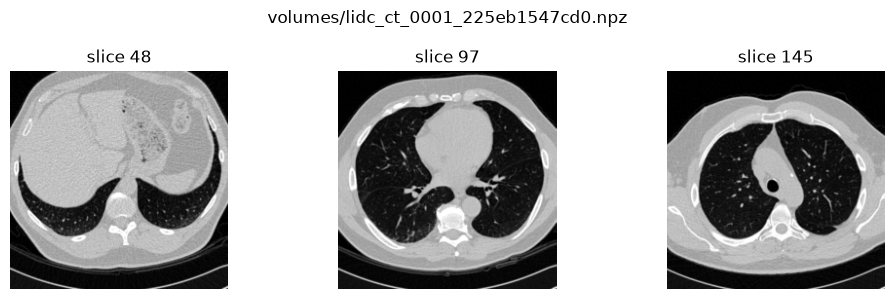

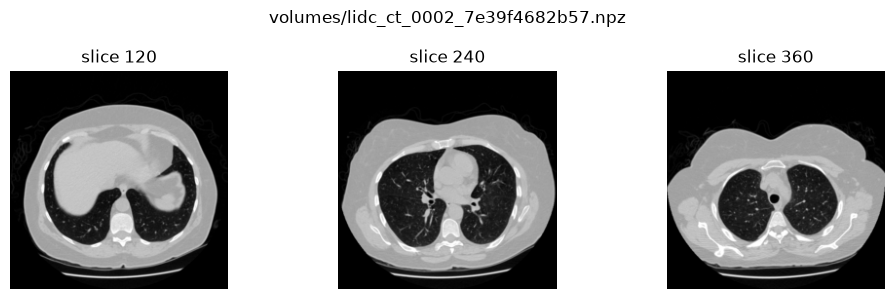

ScalarImage(shape: (1, 224, 224, 194); spacing: (1.00, 1.00, 1.00); orientation: RAS+; dtype: torch.FloatTensor; memory: 37.1 MiB)
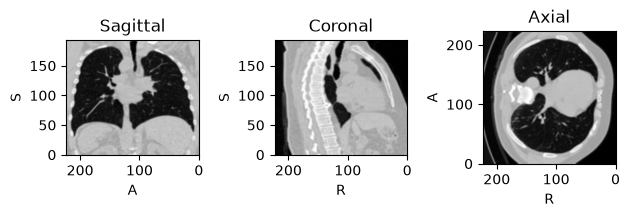

In [4]:
def load_npz_as_torchio(row):
    with np.load(DATASET_DIR / row["volume_path"]) as data:
        volume = data["volume"].astype(np.float32)  # shape: height, width, slices

    tensor = torch.from_numpy(volume).unsqueeze(0)  # shape: channels, height, width, slices
    spacing = (
        float(row.get("spacing_y_mm", 1.0) or 1.0),
        float(row.get("spacing_x_mm", 1.0) or 1.0),
        float(row.get("spacing_z_mm", 1.0) or 1.0),
    )
    return tio.ScalarImage(tensor=tensor, spacing=spacing)


def show_middle_slices(volume, title=""):
    indices = [volume.shape[-1] // 4, volume.shape[-1] // 2, 3 * volume.shape[-1] // 4]
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for ax, index in zip(axes, indices):
        ax.imshow(volume[:, :, index], cmap="gray")
        ax.set_title(f"slice {index}")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

images = []
for _, row in sample.iterrows():
    images.append(load_npz_as_torchio(row))
    with np.load(DATASET_DIR / row["volume_path"]) as data:
        show_middle_slices(data["volume"], title=row["volume_path"])

images[0]


In [5]:
processor = get_processor()
model = get_model().to(device)
model.eval()

texts = ["No lung nodules", "Lung nodules"]
pipeline = ZeroShotImageClassificationPipeline(model, processor)

# Run zero-shot classification for the first CT only to keep the example quick.
pipeline(images[0], texts)


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[{'score': 4.599517706083134e-05, 'label': 'No lung nodules'},
 {'score': 0.9999539852142334, 'label': 'Lung nodules'}]

In [6]:
preprocessed_images = processor.process_images(images)
images_batch = processor.to_images_batch(preprocessed_images).to(device)
print("batch shape:", tuple(images_batch.shape))

with torch.no_grad():
    image_embeds = model.encode_image(
        images_batch,
        pool=True,
        project=True,
        normalize=True,
    ).detach().cpu().numpy()

print("image embeddings:", image_embeds.shape)


batch shape: (2, 1, 192, 192, 192)
image embeddings: (2, 768)


In [8]:
image_embeds

array([[-0.03519536,  0.0050247 , -0.09161559, ..., -0.04397948,
         0.0218658 ,  0.02292097],
       [-0.03519557,  0.00502402, -0.09161659, ..., -0.04397939,
         0.02186977,  0.02292369]], shape=(2, 768), dtype=float32)

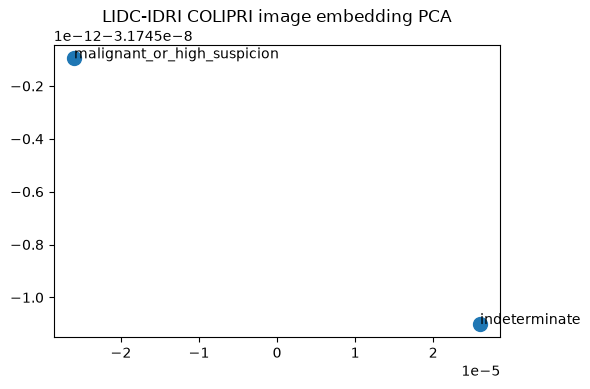

In [7]:
if len(image_embeds) >= 2:
    coords = PCA(n_components=2, random_state=0).fit_transform(image_embeds)
    plt.figure(figsize=(6, 4))
    plt.scatter(coords[:, 0], coords[:, 1], s=100)
    for index, row in sample.iterrows():
        label = row.get("ct_malignancy_class", f"CT {index}")
        plt.text(coords[index, 0], coords[index, 1], label)
    plt.title("LIDC-IDRI COLIPRI image embedding PCA")
    plt.tight_layout()
    plt.show()
else:
    print(image_embeds[0][:20])
